# ReGRID model analysis

### Renewable energy potential

Developed: 30 January, 2026

Note:
- This notebook depends on results generated by the following notebooks:
  - potential_map.ipynb

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os

In [ ]:
# Data for analysis

VRE = ['solar','onwin','of-fx','of-fl']
CASES = ['base','low','mid','high']
CASE_NAME = {'low':'PA+OECM', 'mid':'Enhanced', 'high':'FullProtect', 'sea':'MarineProtect', 'land':'LandProtect', 'base':'HPA'}

output_path = 'output/analysis'
if not os.path.exists(output_path):
    os.makedirs(output_path, exist_ok=True)

# Region list
region_list = pd.read_csv('input/region.csv', index_col='code', dtype={'code':str, 'DSN':str})
REGION = region_list.index.to_list() # All nodes
    
# Technology dataset (Cost, Efficiency, etc.)
P = pd.read_csv(f'input/technology/technology_C1.csv', index_col=0)
P = P[(P['year'] == 2050) & (P['scenario'] == 'moderate')]

# Renewable energy temporal profiles
profile = {}
STEP = 6 # Timestep(h)
profile["solar"] = pd.read_csv('input/%sh/solar_2019.csv' % (STEP), index_col=0)
profile["onwin"] = pd.read_csv('input/%sh/onwind_2019.csv' % (STEP), index_col=0)
profile["of-fx"] = pd.read_csv('input/%sh/ofwind_2019_fixed.csv' % (STEP), index_col=0)
profile["of-fl"] = pd.read_csv('input/%sh/ofwind_2019_float.csv' % (STEP), index_col=0)
profile["river"] = pd.read_csv('input/%sh/river_2019.csv' % (STEP), index_col=0)
profile["geoth"] = pd.read_csv('input/%sh/geothermal_2019.csv' % (STEP), index_col=0)
profile["hydro"] = pd.read_csv('input/%sh/hydro_2019.csv' % (STEP), index_col=0)

# Annual capacity factor for renewables
CF_annual = pd.DataFrame(index=REGION)
for res in profile.keys():
    CF_annual[res] = (profile[res] / STEP).mean()

# Renewable energy potential
potential = {}
for case in CASES:
    potential_VRE_MW = pd.read_csv('input/potential/renewables_potential_MW_%s.csv' % case, index_col='code', dtype={'code':str})
    potential[case] = pd.DataFrame()
    for res in VRE:
        potential[case][res] = (potential_VRE_MW[res] * CF_annual[res] * 8760) # MW -> MWh


USD = 107 # JPY/USD

In [3]:
# Chart paramter
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['font.size'] = 7
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['axes.linewidth'] = 0.5

MAX_WIDTH = 180 / 25.4 # inch in 180mm

HPA : 5844 TWh
PA+OECM : 3947 TWh
Enhanced : 2702 TWh
FullProtect : 1132 TWh
       HPA  PA+OECM  Enhanced  FullProtect
land  2.40     27.6      66.4         94.9
sea   0.16     37.0      62.0         77.0


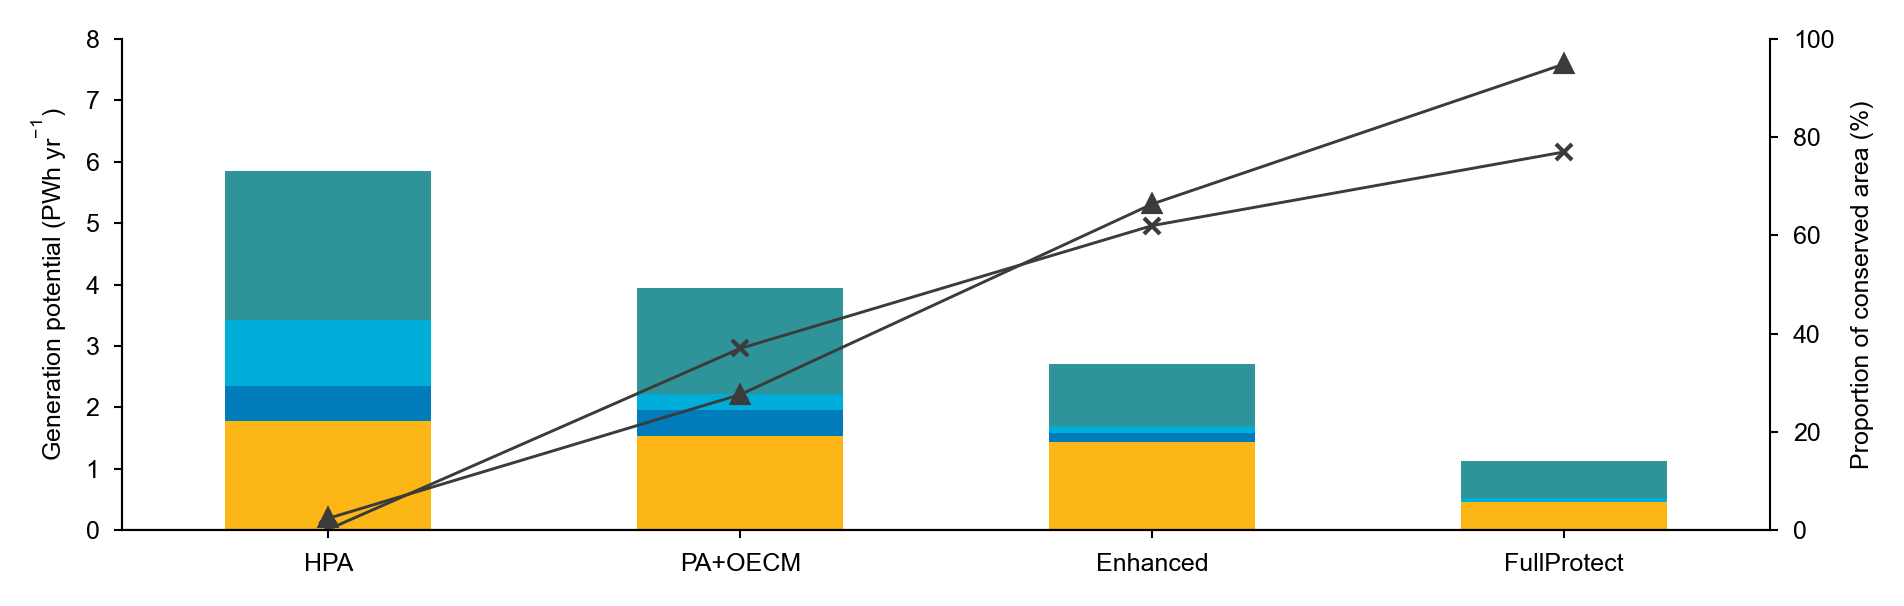

In [ ]:
# Case comparison

def potential_plot(data, line_data, label, line_label, title, ymin, ymax, file_name):
    fig, ax = plt.subplots(1, 1, gridspec_kw={'wspace':0.04}, figsize=[MAX_WIDTH*1,MAX_WIDTH*0.3], dpi=300)

    font_size = 6
    plt.rcParams['font.size'] = font_size
    plt.rcParams['xtick.labelsize'] = font_size
    plt.rcParams['ytick.labelsize'] = font_size

    # Stack plot
    data.plot(kind='bar', stacked=True, ax=ax, color=[P['color'][abr] for abr in data.columns], legend=None, linewidth=0, width=0.5)
    ax.tick_params(bottom=False, axis='y')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel(label)
    ax.set_xlabel("", fontsize=0)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax2 = ax.twinx()
    ax2.plot(line_data['land'], linestyle='-', color="#3B3B3B", linewidth=0.7, marker='^', markersize=4)
    ax2.plot(line_data['sea'], linestyle='-', color="#3B3B3B", linewidth=0.7, marker='x', markersize=4)
    ax2.set_ylabel(line_label)
    ax2.set_ylim(0, 100)
    
    ax2.spines['top'].set_visible(False)

    plt.savefig(f'{output_path}/{file_name}.jpg', bbox_inches='tight', dpi=300)
    plt.savefig(f'{output_path}/{file_name}.pdf', bbox_inches='tight')
    plt.show()


df_potential = pd.DataFrame(index=VRE)
df_conserved_land = pd.DataFrame(index=['land','sea'])

for case in CASES:
    print(CASE_NAME[case], ':', round(potential[case].sum().sum()/1000000), 'TWh')
    df_potential[CASE_NAME[case]] = potential[case].sum()

df_conserved_land[CASE_NAME['base']] = {'land':2.4, 'sea':0.16}
df_conserved_land[CASE_NAME['low']] = {'land':27.6, 'sea':37}
df_conserved_land[CASE_NAME['mid']] = {'land':66.4, 'sea':62}
df_conserved_land[CASE_NAME['high']] = {'land':94.9, 'sea':77}

potential_plot(df_potential.T/1000000000, df_conserved_land.T, 'Generation potential (PWh yr$^{-1}$)', 'Proportion of conserved area (%)', "", 0, 8, 'potential_comparison')